# 📊 Wisconsin Breast Cancer Dataset - Exploratory Data Analysis (EDA)

## Mục tiêu
- Hiểu cấu trúc dữ liệu Wisconsin Diagnostic Breast Cancer
- Phân tích phân phối các đặc trưng
- Kiểm tra mất cân bằng dữ liệu (class imbalance)
- Phân tích tương quan giữa các features
- Xác định features quan trọng

---

## Dataset Information
- **Source**: UCI Machine Learning Repository / scikit-learn
- **Samples**: 569 bệnh nhân
- **Features**: 30 đặc trưng số (real-valued)
- **Target**: Binary (Malignant = 1, Benign = 0)
- **Features**: Được tính từ hình ảnh tế bào núm vú (FNA - Fine Needle Aspirate)

### Feature Groups:
Mỗi group có 10 features (mean, se, worst):
1. **Radius** - Khoảng cách từ tâm đến chu vi
2. **Texture** - Độ lệch chuẩn của giá trị gray-scale
3. **Perimeter** - Chu vi tế bào
4. **Area** - Diện tích tế bào
5. **Smoothness** - Biến thiên local của độ dài radius
6. **Compactness** - (perimeter^2 / area) - 1.0
7. **Concavity** - Độ nghiêm trọng của các phần lõm
8. **Concave points** - Số điểm lõm của contour
9. **Symmetry** - Độ đối xứng
10. **Fractal dimension** - "coastline approximation" - 1

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Custom imports
from src.utils.config import *
from src.utils.helpers import *
from src.data_processing import load_wisconsin_data

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Data

In [2]:
# Load Wisconsin dataset
df = load_wisconsin_data(WISCONSIN_DATA_PATH)

# Display first few rows
print("\n📋 First 5 rows:")
df.head()

⚠️  Data file not found at /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/raw/wisconsin_breast_cancer.csv
📥 Downloading Wisconsin dataset...
✅ Downloaded and saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/raw/wisconsin_breast_cancer.csv
✅ Loaded Wisconsin dataset: 569 samples, 32 features

📋 First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,M


In [3]:
# Dataset info
print("\n📊 Dataset Information:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")


📊 Dataset Information:
Shape: (569, 32)

Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'diagnosis']

Data types:
float64    30
int64       1
str         1
Name: count, dtype: int64

Memory usage: 165.72 KB


## 2. Check Data Quality

In [4]:
# Missing values
print("\n🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found!")
else:
    print(missing[missing > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n📑 Duplicate rows: {duplicates}")
if duplicates == 0:
    print("   ✅ No duplicates found!")


🔍 Missing Values:
   ✅ No missing values found!

📑 Duplicate rows: 0
   ✅ No duplicates found!


In [5]:
# Basic statistics
print("\n📈 Statistical Summary:")
df.describe()


📈 Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 3. Target Variable Analysis (Class Distribution)

### ⚠️ QUAN TRỌNG: Kiểm tra mất cân bằng dữ liệu (Imbalanced Data)
Trong y tế, dữ liệu thường mất cân bằng (ít người bị ung thư hơn người khỏe mạnh)

In [6]:
# Class distribution
print("\n🎯 Target Variable Distribution:")
print("="*60)

# Count and percentage
target_counts = df['target'].value_counts().sort_index()
target_pct = df['target'].value_counts(normalize=True).sort_index() * 100

print(f"Benign (0):    {target_counts[0]:>4d} samples ({target_pct[0]:.2f}%)")
print(f"Malignant (1): {target_counts[1]:>4d} samples ({target_pct[1]:.2f}%)")
print("="*60)

# Imbalance ratio
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️  Dataset is imbalanced - Will need SMOTE or class weighting")
else:
    print("✅ Dataset is relatively balanced")


🎯 Target Variable Distribution:
Benign (0):     212 samples (37.26%)
Malignant (1):  357 samples (62.74%)

Imbalance Ratio: 1.68:1
⚠️  Dataset is imbalanced - Will need SMOTE or class weighting


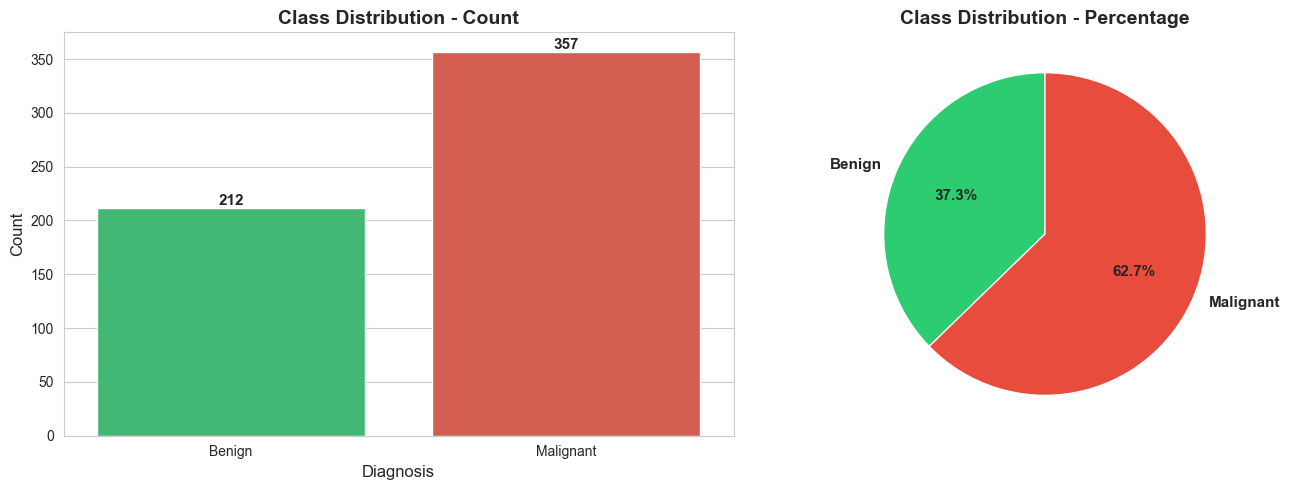

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_class_distribution.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_class_distribution.png')

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
diagnosis_map = {0: 'Benign', 1: 'Malignant'}
df['diagnosis_label'] = df['target'].map(diagnosis_map)

sns.countplot(data=df, x='diagnosis_label', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Class Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add count labels
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Save figure
save_figure(fig, 'wisconsin_class_distribution', RESULTS_DIR)

## 4. Feature Distribution Analysis

In [8]:
# Get feature columns (exclude target and diagnosis)
feature_cols = [col for col in df.columns if col not in ['target', 'diagnosis', 'diagnosis_label']]

print(f"\n📊 Number of features: {len(feature_cols)}")
print(f"\nFeature columns:\n{feature_cols}")


📊 Number of features: 30

Feature columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


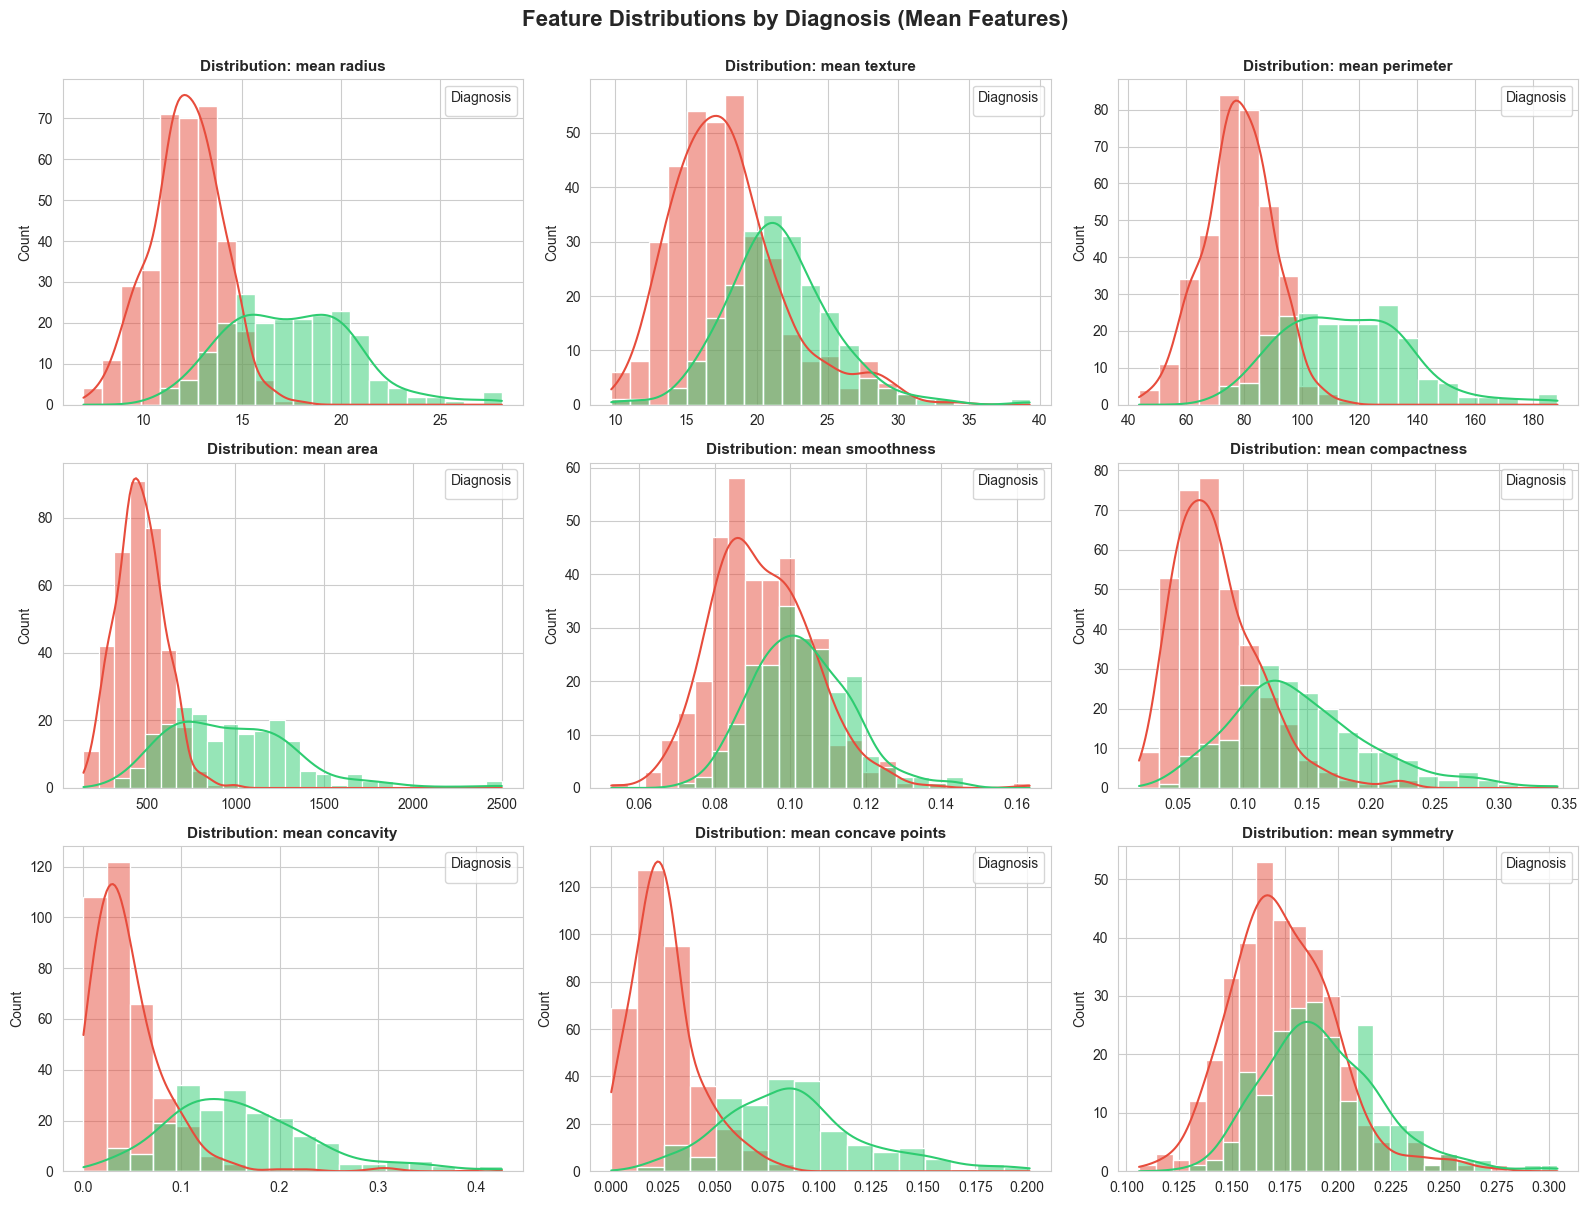

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_feature_distributions.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_feature_distributions.png')

In [9]:
# Distribution of features by diagnosis (sample of 9 features)
sample_features = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity', 
    'mean concave points', 'mean symmetry'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(sample_features):
    sns.histplot(data=df, x=feature, hue='diagnosis_label', 
                 palette=['#2ecc71', '#e74c3c'], kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution: {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].legend(title='Diagnosis', fontsize=9)

plt.suptitle('Feature Distributions by Diagnosis (Mean Features)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_feature_distributions', RESULTS_DIR)

## 5. Box Plots - Identifying Important Features

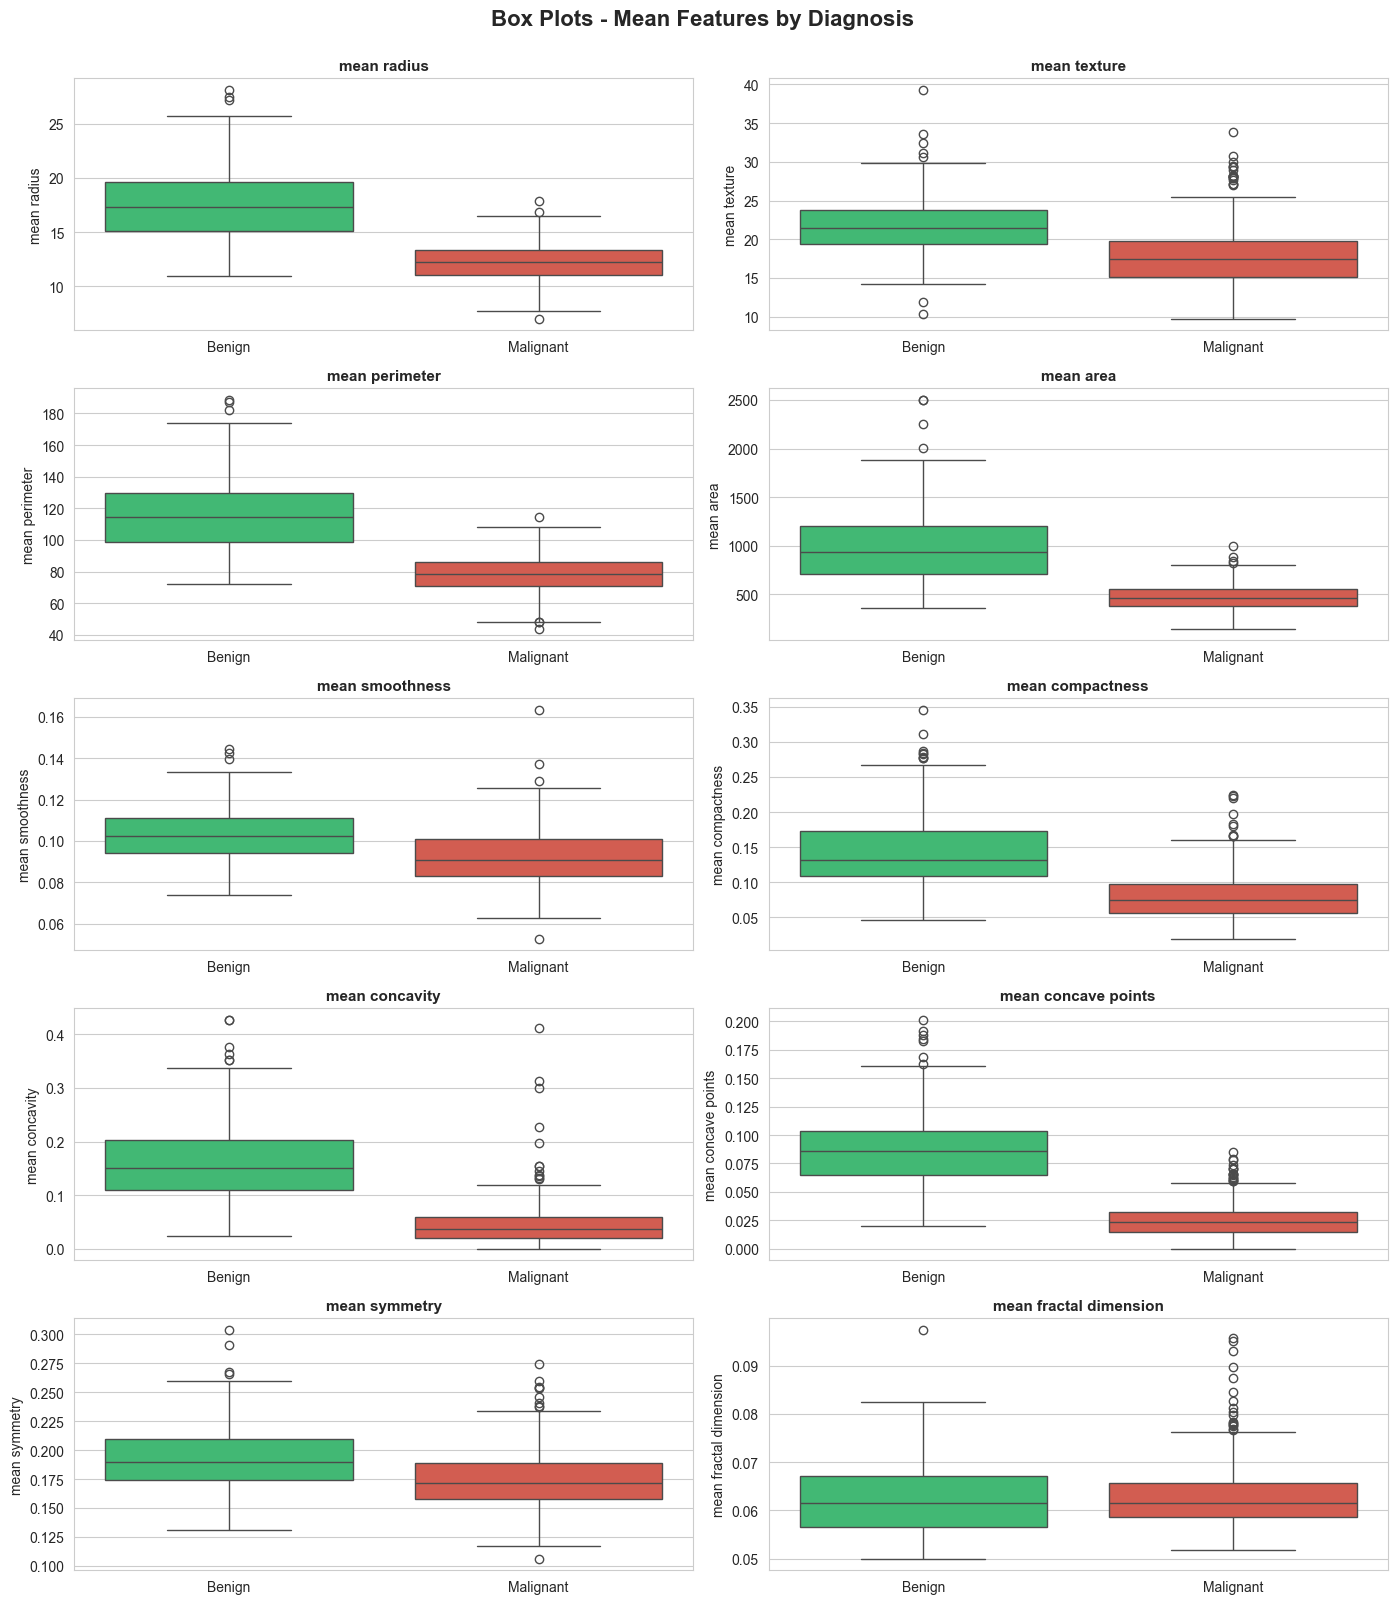

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_boxplots_mean.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_boxplots_mean.png')

In [10]:
# Box plots for mean features
mean_features = [col for col in feature_cols if 'mean' in col]

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.ravel()

for idx, feature in enumerate(mean_features):
    sns.boxplot(data=df, x='diagnosis_label', y=feature, 
                palette=['#2ecc71', '#e74c3c'], ax=axes[idx])
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')

plt.suptitle('Box Plots - Mean Features by Diagnosis', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_boxplots_mean', RESULTS_DIR)

## 6. Correlation Analysis

### Phân tích tương quan để:
- Hiểu mối quan hệ giữa các features
- Phát hiện multicollinearity (có thể cần xử lý)
- Xác định features có tương quan mạnh với target

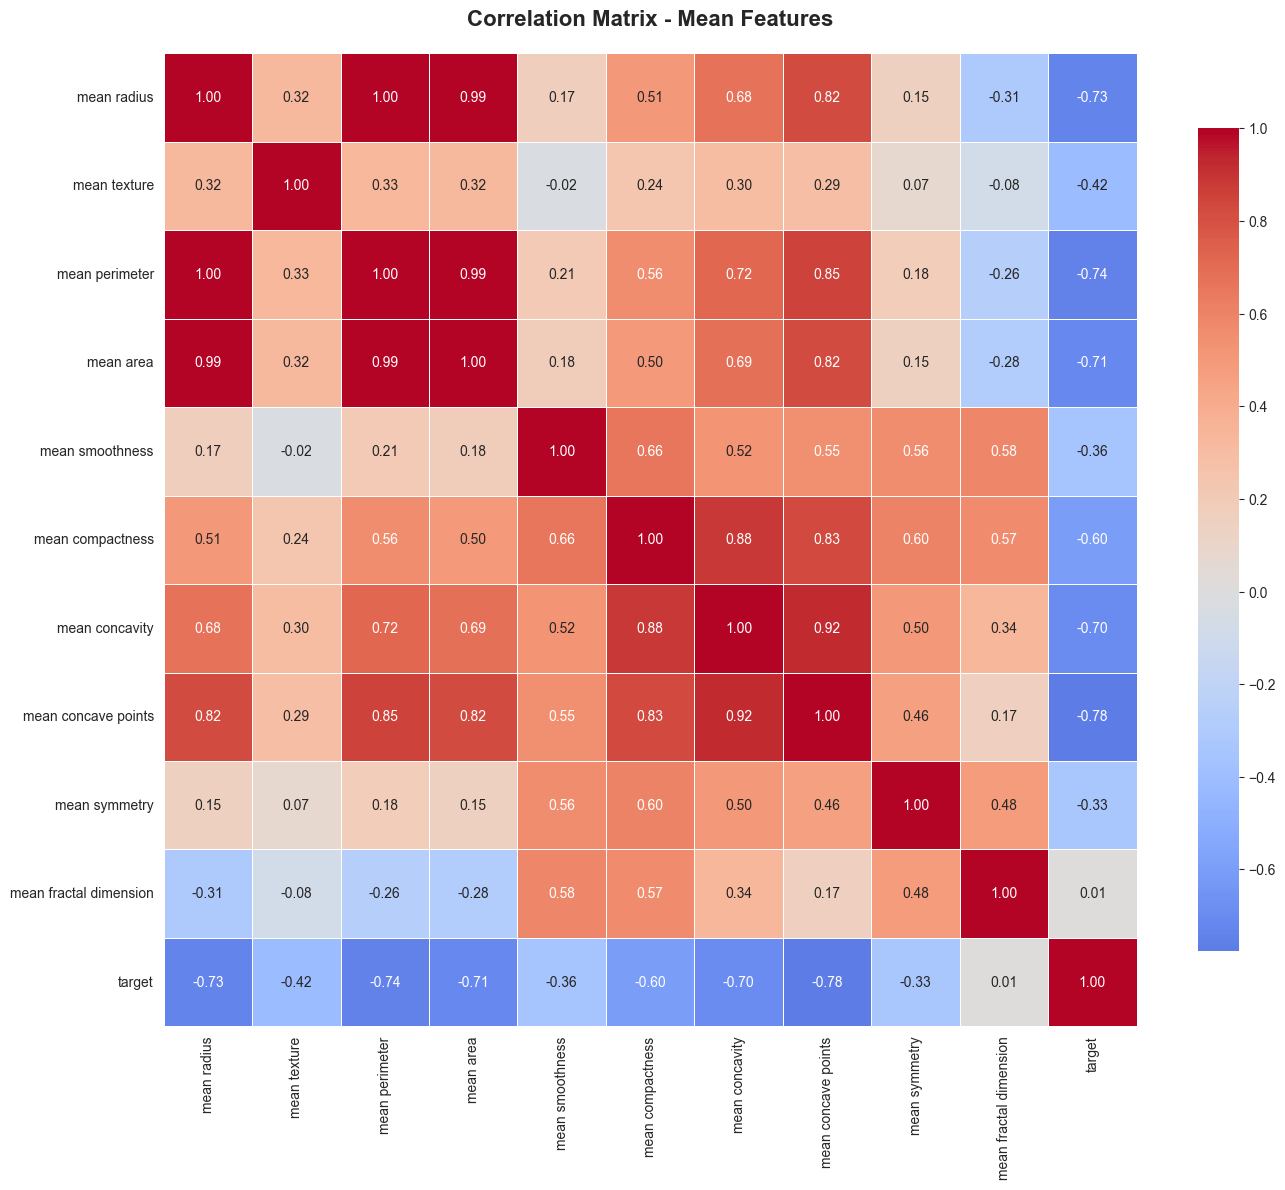

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_correlation_matrix.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_correlation_matrix.png')

In [11]:
# Correlation matrix (mean features only for clarity)
mean_features_df = df[mean_features + ['target']]
corr_matrix = mean_features_df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Mean Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_correlation_matrix', RESULTS_DIR)


🎯 Features Most Correlated with Target (Malignant):
mean fractal dimension    0.012838
mean symmetry            -0.330499
mean smoothness          -0.358560
mean texture             -0.415185
mean compactness         -0.596534
mean concavity           -0.696360
mean area                -0.708984
mean radius              -0.730029
mean perimeter           -0.742636
mean concave points      -0.776614
Name: target, dtype: float64


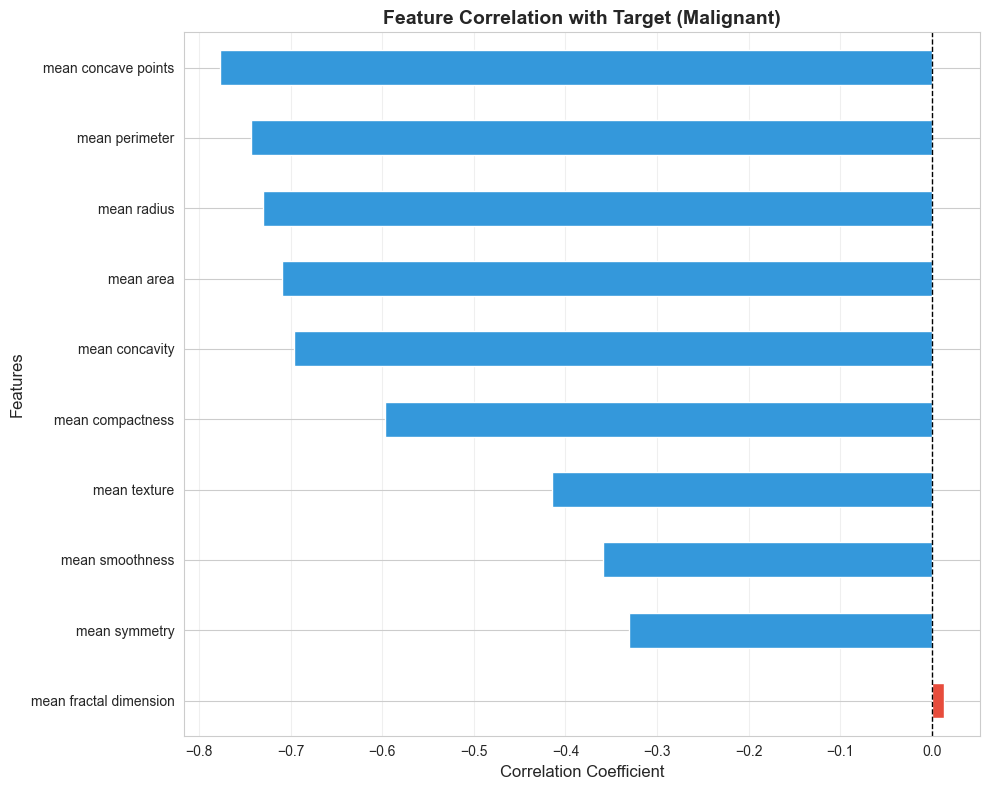

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_target_correlation.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_target_correlation.png')

In [12]:
# Features most correlated with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)

print("\n🎯 Features Most Correlated with Target (Malignant):")
print("="*60)
print(target_corr)
print("="*60)

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
target_corr.plot(kind='barh', color=['#e74c3c' if x > 0 else '#3498db' for x in target_corr], ax=ax)
ax.set_title('Feature Correlation with Target (Malignant)', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_target_correlation', RESULTS_DIR)

## 7. Pairplot - Key Features


📊 Top 5 Features for Pairplot:
['mean concave points', 'mean perimeter', 'mean radius', 'mean area', 'mean concavity']


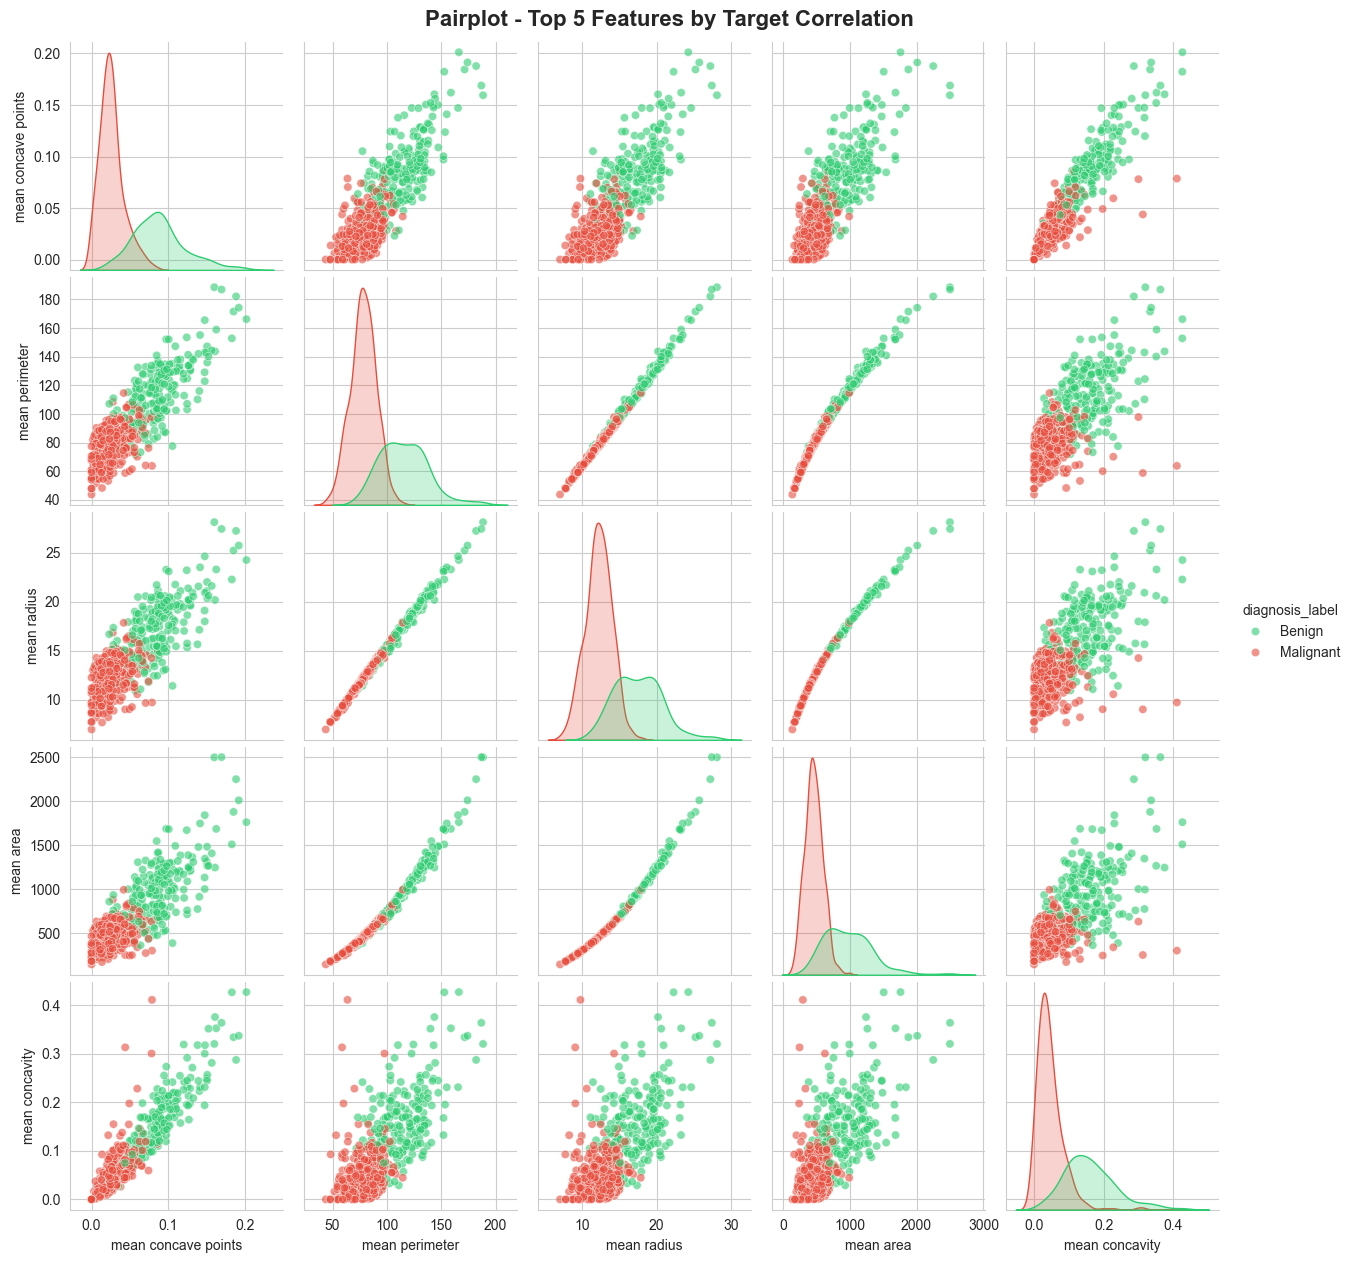

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_pairplot_top5.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_pairplot_top5.png')

In [13]:
# Select top 5 features most correlated with target
top_features = target_corr.abs().nlargest(5).index.tolist()
print(f"\n📊 Top 5 Features for Pairplot:\n{top_features}")

# Pairplot
pairplot_df = df[top_features + ['diagnosis_label']]
g = sns.pairplot(pairplot_df, hue='diagnosis_label', 
                 palette=['#2ecc71', '#e74c3c'],
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot - Top 5 Features by Target Correlation', 
               fontsize=16, fontweight='bold', y=1.01)
plt.show()

save_figure(g.fig, 'wisconsin_pairplot_top5', RESULTS_DIR)

## 8. Summary & Key Findings

### 📊 Data Quality
- ✅ Không có missing values
- ✅ Không có duplicates
- ✅ Tất cả features đều là numeric

### ⚖️ Class Imbalance
- Dataset có mất cân bằng nhẹ (Benign > Malignant)
- **Giải pháp**: Sử dụng SMOTE hoặc class_weight='balanced'

### 🎯 Key Features (High Correlation with Target)
- Các features liên quan đến kích thước (radius, perimeter, area)
- Concave points và concavity
- Worst features (worst radius, worst perimeter, etc.)

### 🔗 Multicollinearity
- Một số features có correlation rất cao với nhau (> 0.9)
- Ví dụ: radius, perimeter, area (về cơ bản đo cùng 1 thứ)
- **Lưu ý**: Tree-based models (RF, XGBoost) handle tốt multicollinearity

### 📈 Next Steps
1. ✅ Preprocessing: Scaling + SMOTE
2. ✅ Train-Val-Test split (stratified)
3. ✅ Train models: Logistic Regression, Random Forest, XGBoost
4. ✅ Evaluation: Clinical metrics (Sensitivity, Specificity, ROC-AUC)
5. ✅ Explainability: SHAP values

In [14]:
# Save processed dataframe for next notebook
df.to_csv(PROCESSED_DATA_DIR / 'wisconsin_eda.csv', index=False)
print(f"\n✅ Data saved to: {PROCESSED_DATA_DIR / 'wisconsin_eda.csv'}")


✅ Data saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/processed/wisconsin_eda.csv


---

## 🎯 Conclusion

EDA hoàn tất! Dataset Wisconsin sẵn sàng cho:
- Preprocessing (Notebook 02)
- Model Training (Notebook 03)
- Evaluation & SHAP (Notebook 04)

### Key Takeaways for Research Paper:
1. Dataset có 569 samples, 30 features
2. Binary classification: Benign vs Malignant
3. Slight class imbalance → Cần SMOTE
4. High correlation features → Features quan trọng rõ ràng
5. Clean data → Không cần extensive cleaning

---

**Next Notebook**: `02_wisconsin_preprocessing.ipynb`